In [145]:
import pandas as pd
import numpy as np

In [146]:
#df = pd.read_csv('data2.csv', names=["Roll","Score"])
df = pd.read_csv('data2.csv')
#df.info()
df.columns = ['Roll','Score']
print(df.head(2))
print(df.shape)
print(df.columns)

      Roll  Score
0  2005058    5.0
1  2005076    3.0
(90, 2)
Index(['Roll', 'Score'], dtype='object')


<font size = '5' color = 'red'>Write a Python program to demonstrate data preprocessing steps: handling missing values, encoding categorical data, 
and feature scaling.</font>

In [147]:
print("Missing values before handling:")
print(df.isnull().sum())

#Missing value handlign with Mean ( Can use Median / Mode / Upward / Backward fill too)
df['Score'].fillna(df['Score'].mean(), inplace=True)

print("\nMissing values after handling:")
print(df.isnull().sum())

#Values with Scores greater than 4
print(df[df['Score'] > 4].head(5))

Missing values before handling:
Roll     0
Score    5
dtype: int64

Missing values after handling:
Roll     0
Score    0
dtype: int64
       Roll  Score
0   2005058    5.0
3   2005150    5.0
7   2005179    5.0
10  2005278    5.0
14  2005324    5.0


C:\Users\KIIT0001\AppData\Local\Temp\ipykernel_9656\2583584070.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Score'].fillna(df['Score'].mean(), inplace=True)


In [148]:
#Scaling
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
df['Score_Scaled'] = scaler.fit_transform(df[['Score']])

print("\nDataframe after preprocessing:")
print(df.head(5))


Dataframe after preprocessing:
      Roll  Score  Score_Scaled
0  2005058    5.0      1.123767
1  2005076    3.0     -1.177924
2  2005119    4.0     -0.027079
3  2005150    5.0      1.123767
4  2005161    3.0     -1.177924


<font size = '5' color = 'orange'>Load a sample dataset using pandas (e.g., Iris or a custom dataset).</font>

In [149]:
spotdf = pd.read_csv('iris.csv')
print(spotdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


<font size = '5' color = 'yellow'>Plot the distribution of a feature using matplotlib.pyplot.hist().</font>

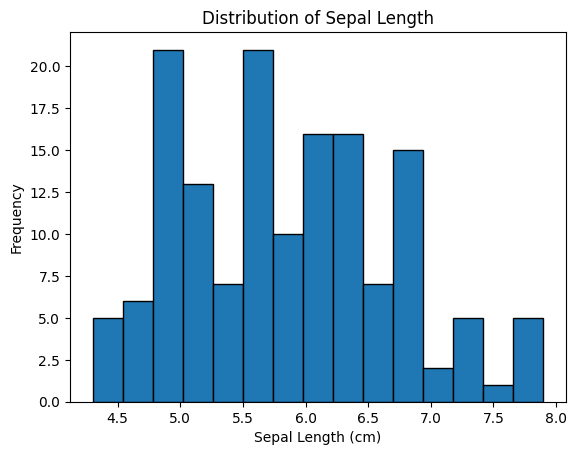

In [150]:
import matplotlib.pyplot as plt

plt.hist(spotdf['SepalLengthCm'], bins=15, edgecolor='black')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')
plt.show()

<font size = '5' color = 'lightgreen'>Create scatter plots to understand relationships between features using seaborn.scatterplot().</font>

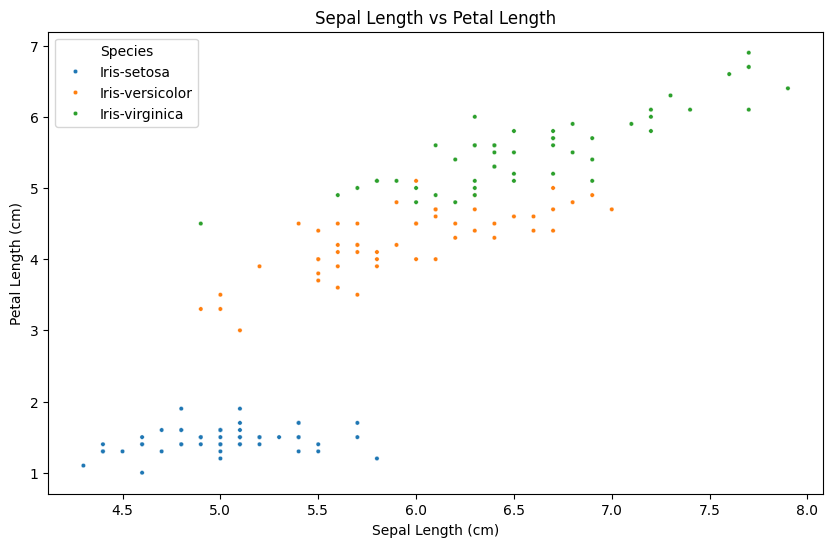

In [151]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=spotdf, x='SepalLengthCm', y='PetalLengthCm', hue='Species',s=10)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Sepal Length vs Petal Length')
plt.show()

<font size = '5' color = 'lightblue'>Use a correlation heatmap to find the relationship between multiple features with seaborn.heatmap().</font>

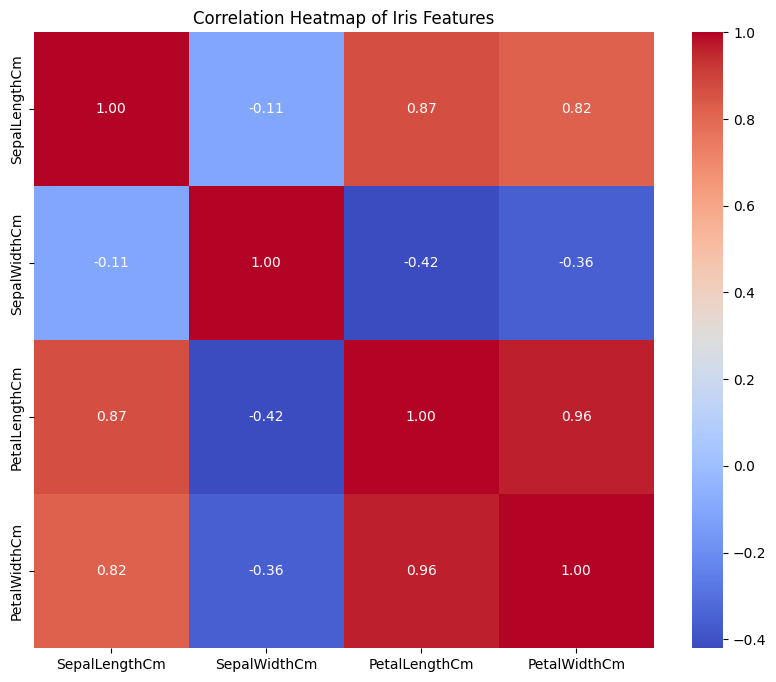

In [152]:
# Select only numeric columns for correlation
spotdf.drop('Species', axis=1, inplace=True)
spotdf.drop('Id', axis=1, inplace=True)

plt.figure(figsize=(10, 8))
sns.heatmap(spotdf.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Iris Features')
plt.show()